In [1]:
from nptdms import TdmsFile
from nptdms import tdms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import decimate
from scipy.signal import detrend
import os
from scipy import signal
from scipy.signal import butter, filtfilt, detrend, decimate
%config InlineBackend.figure_format = 'retina'

#### copy with psd

In [2]:
das_30min = np.load('das_30min_1601ch_d.npy')

In [4]:
das_30min_1 = np.zeros((das_30min.shape))

In [6]:
fs = 100  # sample freq
nyquist = fs / 2  # Nyquist freq
lowcut = 0.5  # min freq
highcut = 30.0  # high freq

def butter_bandpass(lowcut,highcut, fs, order=5):
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low,high], btype='band')
    return b, a

In [7]:
b, a = butter_bandpass(lowcut, highcut, fs)

In [8]:
for i in range(len(das_30min)):
    
    x = np.linspace(0,1800,180000,endpoint = False)
    coeffs = np.polyfit(x, das_30min[i], 4)
    dasradians_1 = das_30min[i] - np.polyval(coeffs, x)
    dasradians_1 = dasradians_1 - np.mean(dasradians_1)
    dasradians_1 = signal.filtfilt(b, a, dasradians_1)
    das_30min_1[i] = dasradians_1

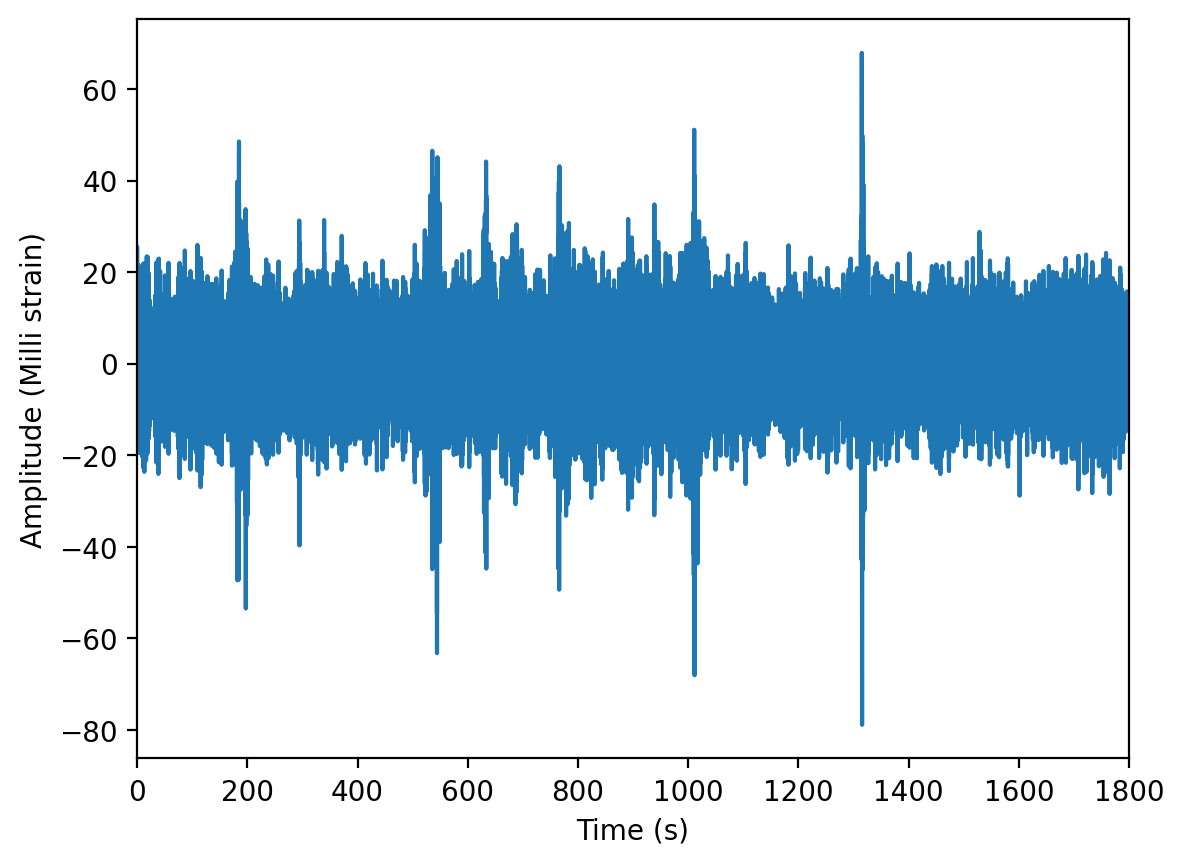

In [9]:
plt.figure()
plt.plot(np.arange(0,1800,0.01), das_30min_1[200])
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (Milli strain)')

plt.xlim(0,1800)
plt.show()

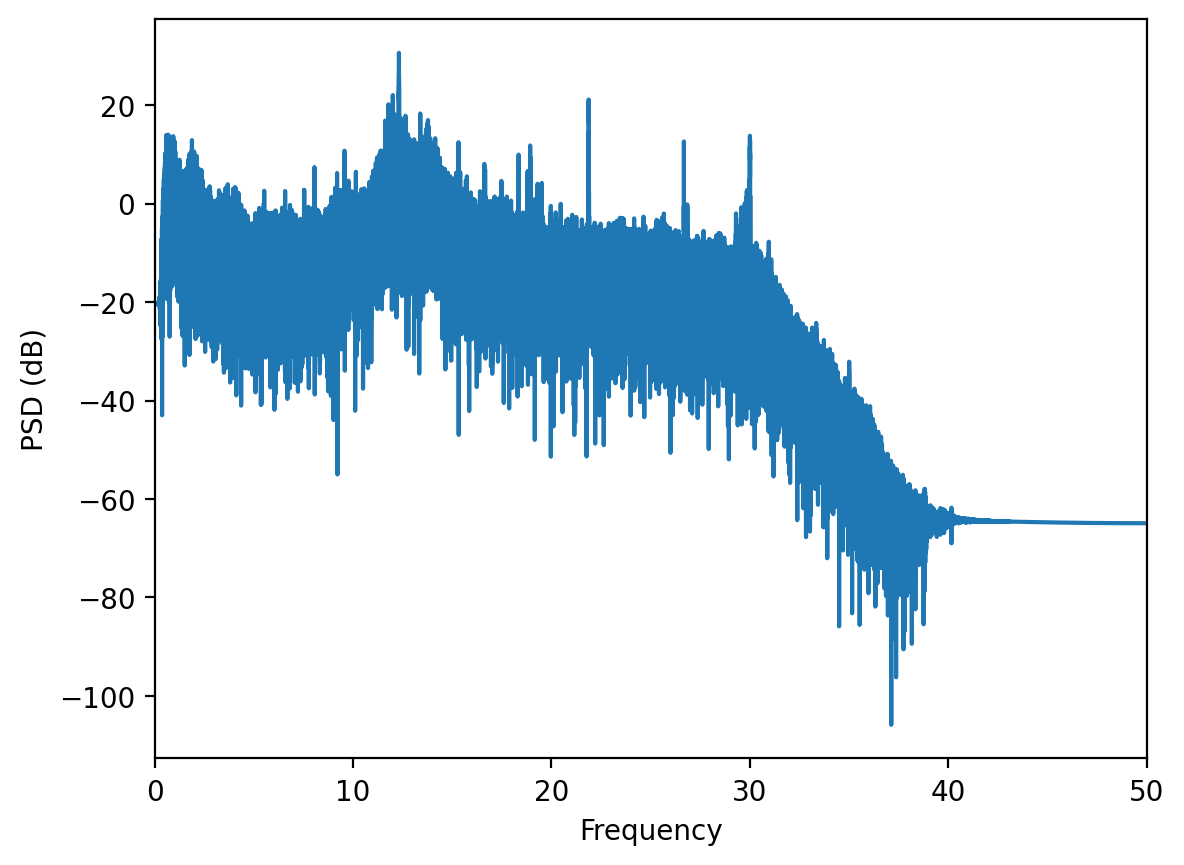

In [11]:
fig,ax = plt.subplots()

n = das_30min_1[200].shape[0]
dt = 0.01
fhat = np.fft.fft((das_30min_1[200]), n)

amp_spec = abs(fhat)**2 / n/fs
amp_db = 10 * np.log10(amp_spec)

freq = (1/(dt*n)) * np.arange(n)
L = np.arange(1,np.floor(n/2),dtype = 'int')
ax.plot(freq[L],amp_db[L])
# plt.yscale('log')
ax.set_xlabel('Frequency')
ax.set_ylabel('PSD (dB)')
ax.set_xlim(xmin = 0,xmax = 50)
# ax.set_yscale('log')
plt.show()

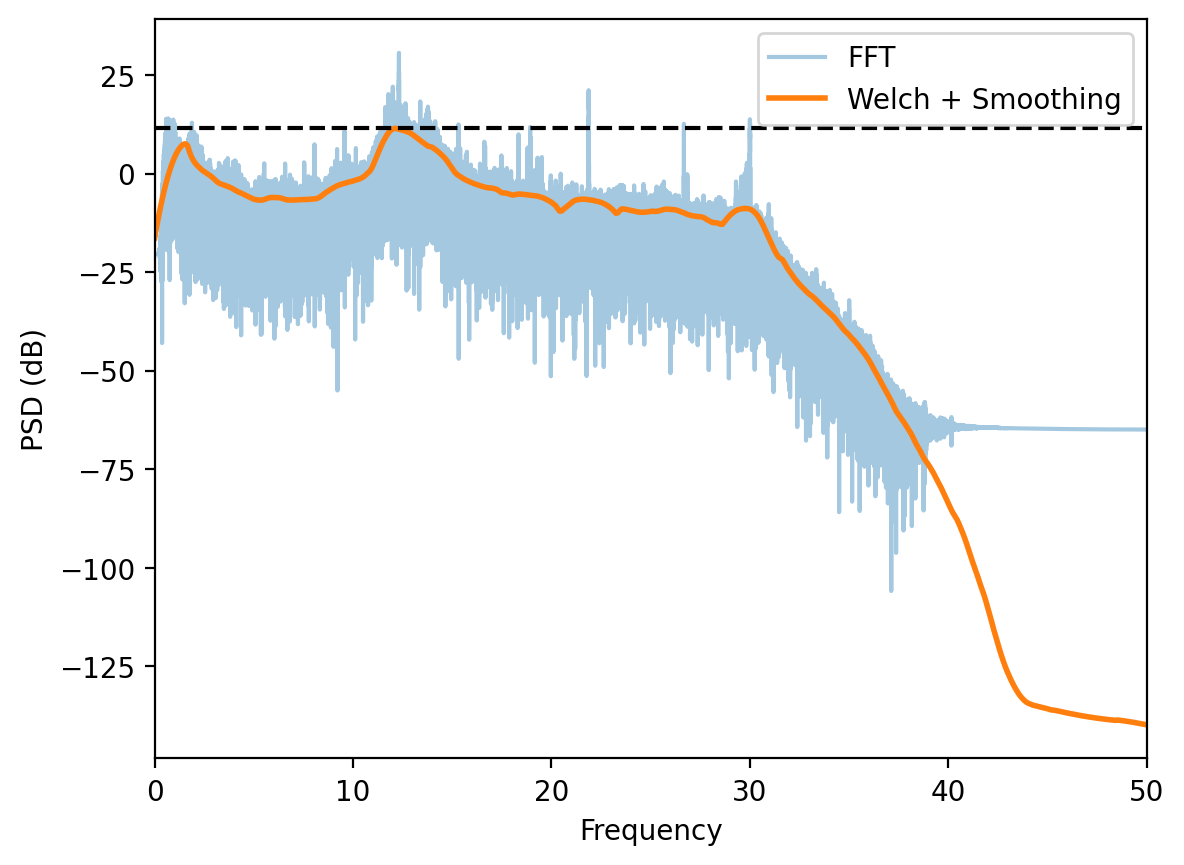

In [12]:
from scipy.signal import welch
from scipy.signal import savgol_filter

signal = das_30min_1[200]

# FFT method
fhat = np.fft.fft(signal)
freqs = np.fft.fftfreq(len(signal), d=1/fs)
mask = freqs >= 0
psd_fft = (np.abs(fhat)**2) / (len(signal)*fs)
psd_fft_db = 10 * np.log10(psd_fft[mask])

# Welch method
f_welch, psd_welch = welch(signal, fs=fs, nperseg=1024)
psd_welch_db = 10 * np.log10(psd_welch)
psd_welch_smooth = savgol_filter(psd_welch_db, 31, 2)


# compare with tradition fft and Welch results.
plt.figure()
plt.plot(freqs[mask], psd_fft_db, alpha=0.4, label="FFT")
plt.plot(f_welch, psd_welch_smooth, label="Welch + Smoothing", lw=2)
plt.axhline(max(psd_welch_smooth), color="k", linestyle="--")
plt.xlim(xmin = 0,xmax = 50)
plt.xlabel('Frequency')
plt.ylabel('PSD (dB)')
plt.legend()
plt.show()

In [15]:
psd_day = np.zeros((das_30min_1.shape[0],psd_welch_smooth.shape[0]))

In [16]:
for i in range(len(psd_day)):
    f_welch, psd_welch = welch(das_30min_1[i], fs=fs, nperseg=1024)
    psd_welch_db = 10 * np.log10(psd_welch)
    psd_welch_smooth = savgol_filter(psd_welch_db, 31, 2)
    psd_day[i] = psd_welch_smooth

In [17]:
psd_day = psd_day.T

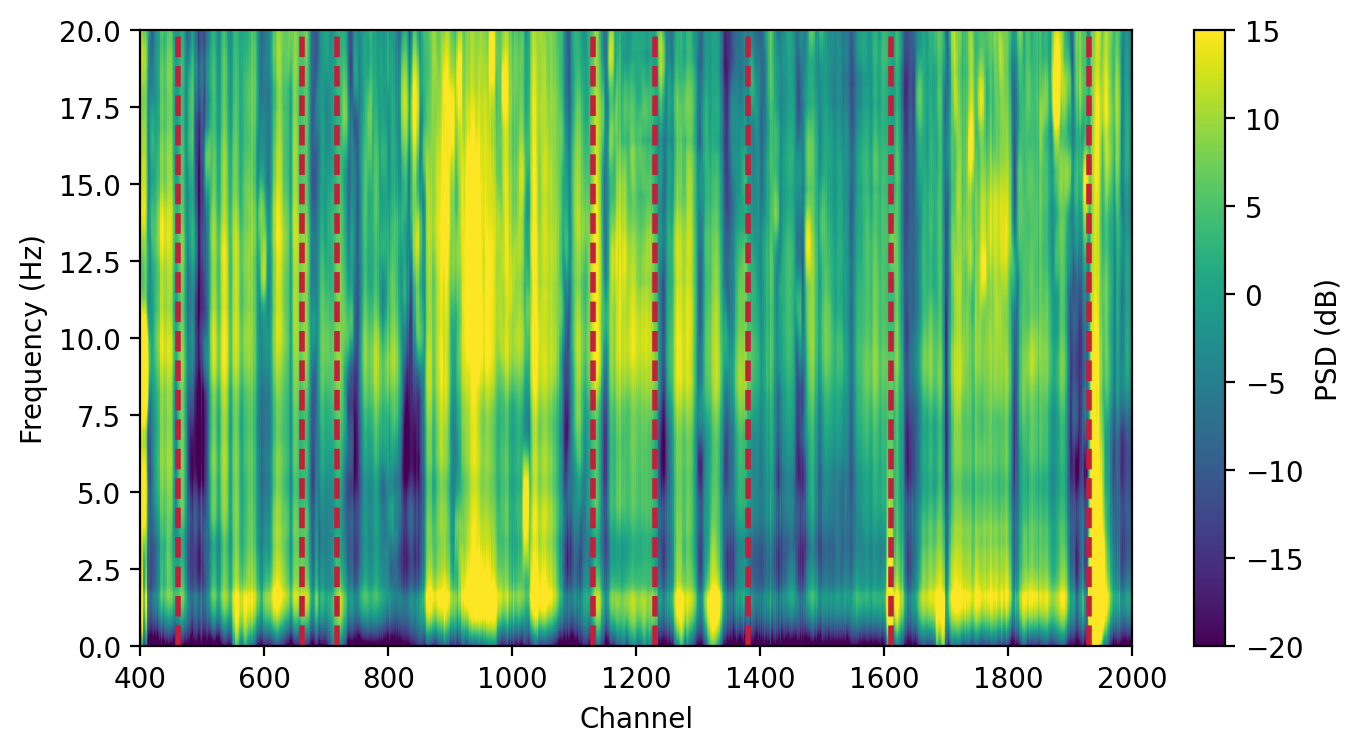

In [18]:
fig, ax = plt.subplots(figsize=(8,4))
im1 = ax.imshow(psd_day, aspect='auto',extent=[400, 2000, min(f_welch), max(f_welch)],
                    origin='lower',
                    # cmap = 'bwr',
                    vmin=-20, vmax=15)
               # )
ax.set_xlabel('Channel')
ax.set_ylabel('Frequency (Hz)')

ax.set_ylim(0, 20)
    
cbar = fig.colorbar(im1,ax = ax)
cbar.set_label("PSD (dB)")

plt.axvline(460, c = "#C41E3A",lw = 2, linestyle="--")
plt.axvline(660, c = "#C41E3A",lw = 2, linestyle="--")

plt.axvline(717, c = "#C41E3A",lw = 2, linestyle="--")
plt.axvline(1130, c = "#C41E3A",lw = 2, linestyle="--")

plt.axvline(1230, c = "#C41E3A",lw = 2, linestyle="--")
plt.axvline(1380, c = "#C41E3A",lw = 2, linestyle="--")


plt.axvline(1610, c = "#C41E3A",lw = 2, linestyle="--")
plt.axvline(1930, c = "#C41E3A",lw = 2, linestyle="--")

# # ax.set_xlim(datetime(2024, 10, 1, 21, 42, 30), datetime(2024, 10, 1, 21, 44, 30))
# ax.set_xlim(datetime(2024, 10, 1, 21, 42, 45), datetime(2024, 10, 1, 21, 43, 20))

# ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
# ax.tick_params(axis='x', which='both', direction='in')  
# ax.tick_params(axis='x', rotation=30)

# ax.invert_yaxis()
fig.savefig('snr_analyzes_legend.png', dpi=600,bbox_inches = 'tight')

plt.show()

In [19]:
psd_night = np.load('psd_night_2d.npy')

In [20]:
das_d_abs = pd.read_excel("D_das_abs.xlsx", index_col=0)
das_n_abs = pd.read_excel("N_das_abs.xlsx", index_col=0)
das_d = pd.read_excel("D_das.xlsx", index_col=0)
das_n = pd.read_excel("N_das.xlsx", index_col=0)
das_d_max = das_d.loc[:,[f'max{i+1}' for i in range(5)]].max(axis=1)
das_d_min = das_d.loc[:,[f'min{i+1}' for i in range(5)]].min(axis=1)
das_d_abs_max = das_d_abs.loc[:,[f'max{i+1}' for i in range(5)]].max(axis=1)
das_d_abs_min = das_d_abs.loc[:,[f'min{i+1}' for i in range(5)]].min(axis=1)

In [21]:
das_n_max = das_n.loc[:,[f'max{i+1}' for i in range(5)]].max(axis=1)
das_n_min = das_n.loc[:,[f'min{i+1}' for i in range(5)]].min(axis=1)
das_n_abs_max = das_n_abs.loc[:,[f'max{i+1}' for i in range(5)]].max(axis=1)
das_n_abs_min = das_n_abs.loc[:,[f'min{i+1}' for i in range(5)]].min(axis=1)

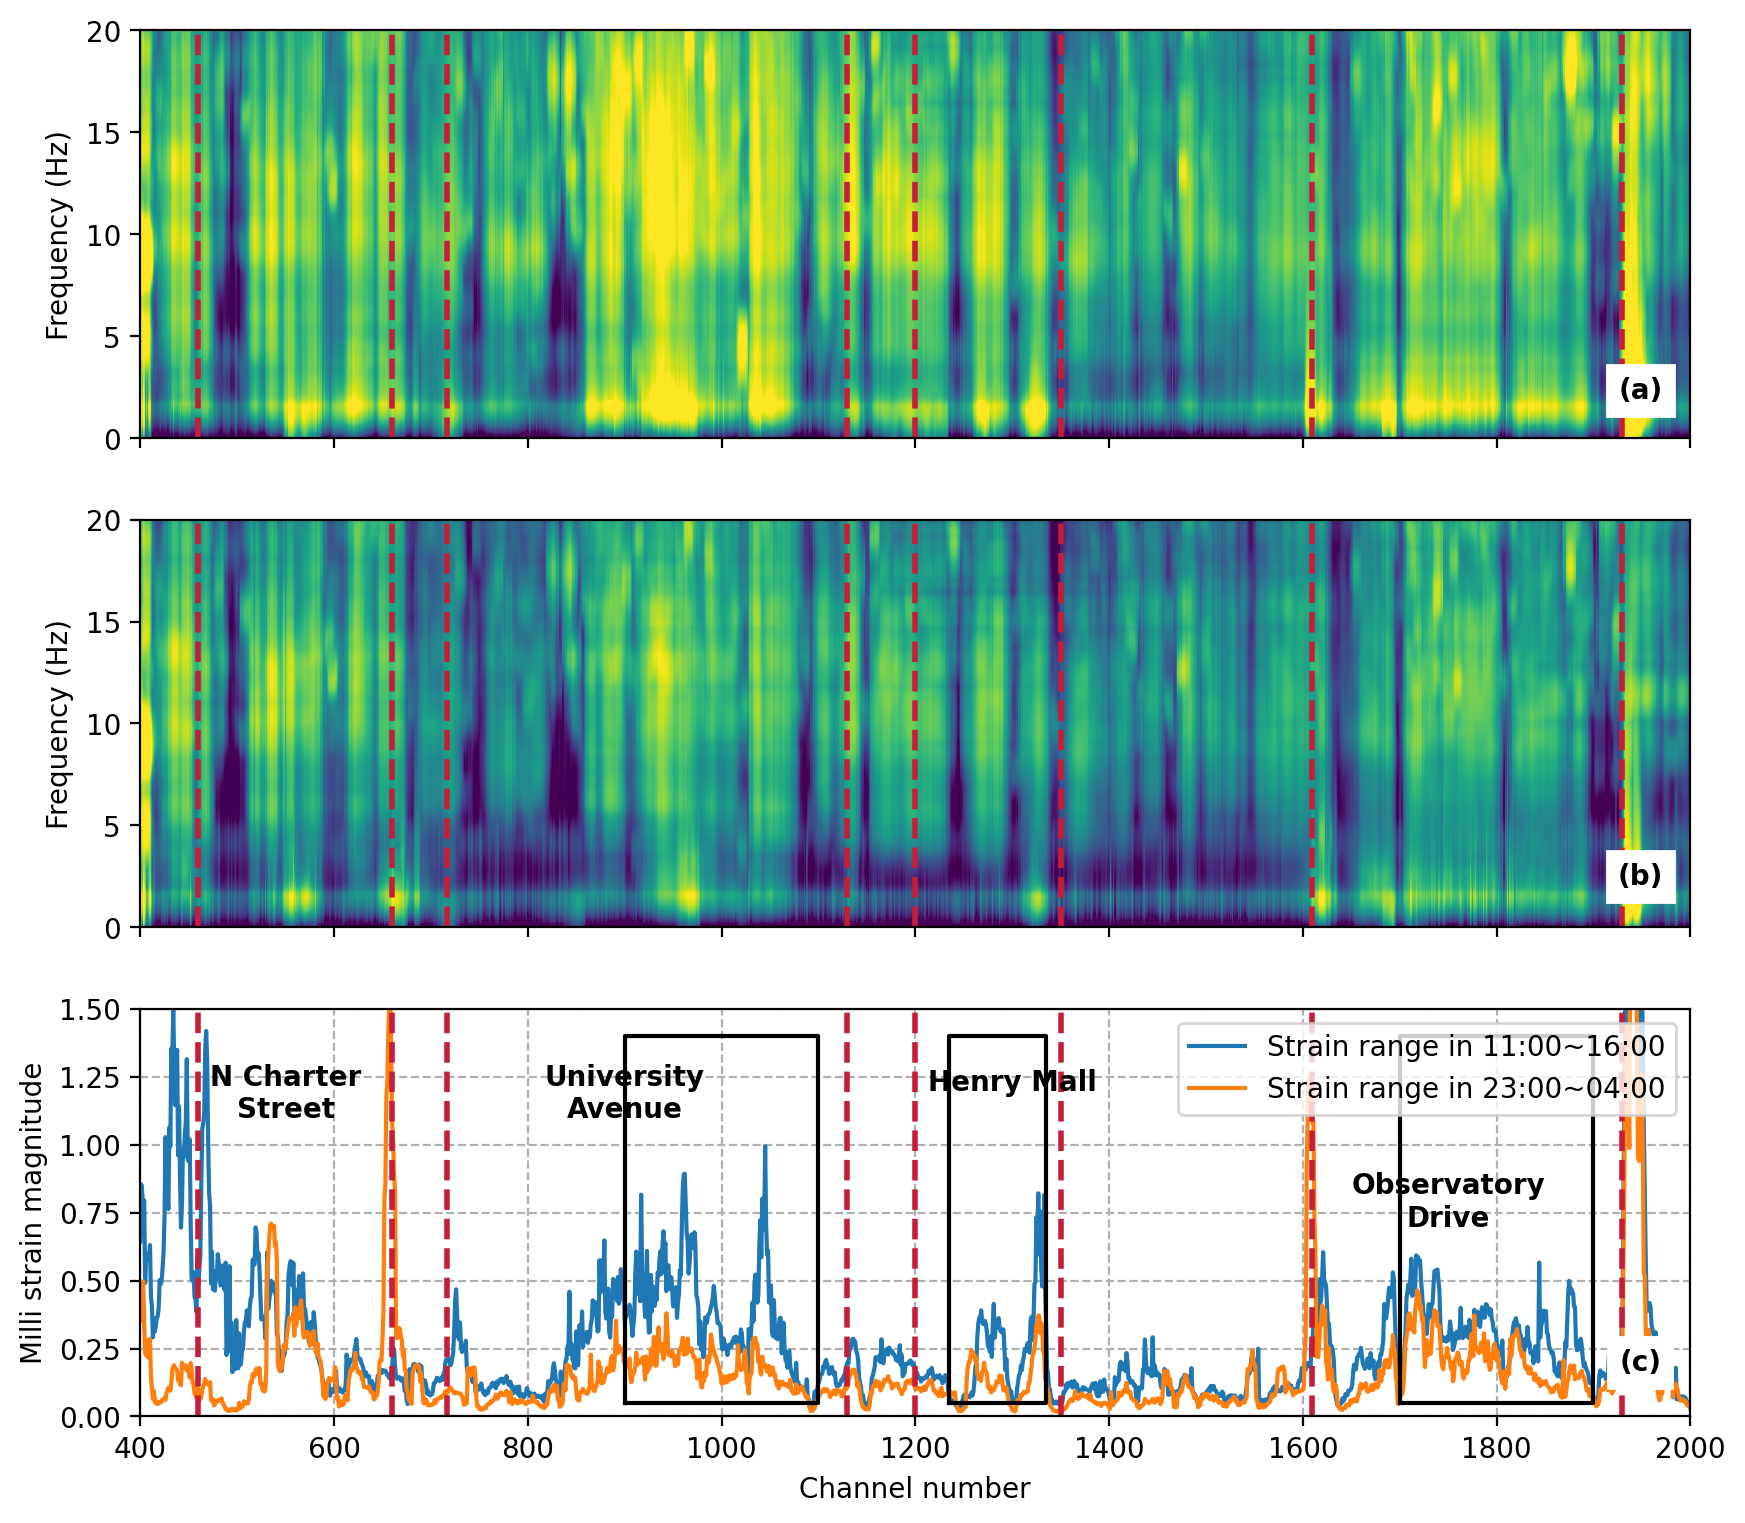

In [26]:
fig, axs = plt.subplots(3,1,figsize = (10,9),sharex = True)

#############################################################################################

im1 = axs[0].imshow(psd_day, aspect='auto',extent=[400, 2000, min(f_welch), max(f_welch)],
                    origin='lower',
                    # cmap = 'bwr',
                    vmin=-20, vmax=15)
               # )

axs[0].set_ylabel('Frequency (Hz)')

# cbar = fig.colorbar(im1,ax = axs[0])
# cbar.set_label("PSD (dB)")

axs[0].set_ylim(0, 20)

axs[0].axvline(460, c = "#C41E3A",lw = 2, linestyle="--")
axs[0].axvline(660, c = "#C41E3A",lw = 2, linestyle="--")

axs[0].axvline(717, c = "#C41E3A",lw = 2, linestyle="--")
axs[0].axvline(1130, c = "#C41E3A",lw = 2, linestyle="--")

axs[0].axvline(1200, c = "#C41E3A",lw = 2, linestyle="--")
axs[0].axvline(1350, c = "#C41E3A",lw = 2, linestyle="--")

axs[0].axvline(1610, c = "#C41E3A",lw = 2, linestyle="--")
axs[0].axvline(1930, c = "#C41E3A",lw = 2, linestyle="--")

#############################################################################################

im1 = axs[1].imshow(psd_night, aspect='auto',extent=[400, 2000, min(f_welch), max(f_welch)],
                    origin='lower',
                    # cmap = 'bwr',
                    vmin=-20, vmax=15)
               # )

axs[1].set_ylabel('Frequency (Hz)')

axs[1].set_ylim(0, 20)

axs[1].axvline(460, c = "#C41E3A",lw = 2, linestyle="--")
axs[1].axvline(660, c = "#C41E3A",lw = 2, linestyle="--")

axs[1].axvline(717, c = "#C41E3A",lw = 2, linestyle="--")
axs[1].axvline(1130, c = "#C41E3A",lw = 2, linestyle="--")

axs[1].axvline(1200, c = "#C41E3A",lw = 2, linestyle="--")
axs[1].axvline(1350, c = "#C41E3A",lw = 2, linestyle="--")

axs[1].axvline(1610, c = "#C41E3A",lw = 2, linestyle="--")
axs[1].axvline(1930, c = "#C41E3A",lw = 2, linestyle="--")

#############################################################################################


# axs[1].fill_between(np.arange(400,2001), das_d_abs_max/1000, das_d_abs_min/1000, alpha=0.5,color ='#9999FF',label = 'Strain range in 11AM~4PM' )
axs[2].plot(np.arange(400,2001), (das_d_abs_max/1000+das_d_abs_min/1000)/2,label = 'Strain range in 11:00~16:00' )

# axs[1].fill_between(np.arange(400,2001), das_n_abs_max/1000, das_n_abs_min/1000, alpha=0.5,label = 'Strain range in 11PM~4AM'  )
axs[2].plot(np.arange(400,2001), (das_n_abs_max/1000+das_n_abs_min/1000)/2,label = 'Strain range in 23:00~04:00' )

axs[2].plot([717,717],[0,1.5],ls = '--',c = "#C41E3A",lw = 2)
axs[2].plot([1130,1130],[0,1.5],ls = '--',c = "#C41E3A",lw = 2)
axs[2].plot([900,1100,1100,900,900],[0.05,0.05,1.4,1.4,0.05],c = "k",lw = 1.5)

axs[2].text(900,1.1,'University\nAvenue',ha = 'center',fontweight = 'bold')

axs[2].plot([1235,1335,1335,1235,1235],[0.05,0.05,1.4,1.4,0.05],c = "k",lw = 1.5)
axs[2].plot([1200,1200],[0,1.5],ls = '--',c = "#C41E3A",lw = 2)
axs[2].plot([1350,1350],[0,1.5],ls = '--',c = "#C41E3A",lw = 2)

axs[2].text(1300,1.2,'Henry Mall',ha = 'center',fontweight = 'bold')

axs[2].plot([1700,1900,1900,1700,1700],[0.05,0.05,1.4,1.4,0.05],c = "k",lw = 1.5)
axs[2].plot([1610,1610],[0,1.5],ls = '--',c = "#C41E3A",lw = 2)
axs[2].plot([1930,1930],[0,1.5],ls = '--',c = "#C41E3A",lw = 2)

axs[2].text(1750,0.7,'Observatory\nDrive',ha = 'center',fontweight = 'bold')

# axs[1].plot([500,600,600,500,500],[0.05,0.05,1.4,1.4,0.05],ls = '--',c = "#C41E3A",lw = 2)
axs[2].text(550,1.1,'N Charter\nStreet',ha = 'center',fontweight = 'bold')
axs[2].plot([460,460],[0,1.5],ls = '--',c = "#C41E3A",lw = 2)
axs[2].plot([660,660],[0,1.5],ls = '--',c = "#C41E3A",lw = 2)

axs[2].grid(ls='--')

axs[2].set_xlabel('Channel number')
axs[2].set_ylabel('Milli strain magnitude')
# ax.text(1940,0.1,'(b)',fontweight = 'bold')

axs[2].set_xlim(400,2000)
axs[2].set_ylim(0,1.5)
axs[2].legend(loc='upper right')

fig.text(0.875, 0.68, '(a)', ha='center', va='center', fontweight='bold', bbox=dict(facecolor='white',edgecolor = 'w'))
fig.text(0.875, 0.41, '(b)', ha='center', va='center', fontweight='bold', bbox=dict(facecolor='white',edgecolor = 'w'))
fig.text(0.875, 0.14, '(c)', ha='center', va='center', fontweight='bold', bbox=dict(facecolor='white',edgecolor = 'w'))

fig.savefig('snr_analyzes_1010.png', dpi=600,bbox_inches = 'tight')

plt.show()